In [ ]:
query = """
SELECT *
FROM `ordermetrics360.ordermetrics360_marts.mart_revenue_trend`P
"""

df = client.query(query).to_dataframe()

df.shape

/Users/student/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(24, 4)

In [3]:
df.head()

,order_month,order_count,revenue,average_order_value
0,2016-09-01,2,207.86,103.930000
1,2016-10-01,293,44507.30,151.902048
2,2016-12-01,1,10.90,10.900000
3,2017-01-01,787,120098.27,152.602630
4,2017-02-01,1718,244959.35,142.584022


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_month          24 non-null     dbdate 
 1   order_count          24 non-null     Int64  
 2   revenue              24 non-null     float64
 3   average_order_value  24 non-null     float64
dtypes: Int64(1), dbdate(1), float64(2)
memory usage: 920.0 bytes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_month          24 non-null     dbdate 
 1   order_count          24 non-null     Int64  
 2   revenue              24 non-null     float64
 3   average_order_value  24 non-null     float64
dtypes: Int64(1), dbdate(1), float64(2)
memory usage: 920.0 bytes


In [6]:
df.isnull().sum()


order_month            0
order_count            0
revenue                0
average_order_value    0
dtype: int64

In [7]:
df[df["revenue"].isnull()]

,order_month,order_count,revenue,average_order_value


In [8]:
df[df["order_month"] == "2018-10-01"]

,order_month,order_count,revenue,average_order_value


In [9]:
df.iloc[23]


order_month            2018-09-01
order_count                     1
revenue                     145.0
average_order_value         145.0
Name: 23, dtype: object

In [10]:
query = """
SELECT
    order_id,
    item_revenue,
    freight_revenue,
    total_payment_value
FROM `ordermetrics360.int_orders_joined`
WHERE DATE_TRUNC(DATE(order_purchase_timestamp), MONTH) = '2018-10-01'
"""

check = client.query(query).to_dataframe()
check

/Users/student/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_id,item_revenue,freight_revenue,total_payment_value
0,a2ac6dad85cf8af5b0afb510a240fe8c,NaN,NaN,197.55
1,616fa7d4871b87832197b2a137a115d2,NaN,NaN,80.38
2,10a045cdf6a5650c21e9cfeb60384c16,NaN,NaN,89.71
3,b059ee4de278302d550a3035c4cdb740,NaN,NaN,222.03


In [11]:
query = """
SELECT
    table_schema,
    table_name
FROM `ordermetrics360.region-asia-south1.INFORMATION_SCHEMA.TABLES`
WHERE table_name LIKE '%int_orders_joined%'
"""

client.query(query).to_dataframe()

/Users/student/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,table_schema,table_name
0,ordermetrics360,int_orders_joined


In [12]:
query = """
SELECT
    order_id,
    item_revenue,
    freight_revenue,
    total_payment_value
FROM `ordermetrics360.ordermetrics360.int_orders_joined`
WHERE DATE_TRUNC(DATE(order_purchase_timestamp), MONTH) = '2018-10-01'
"""

check = client.query(query).to_dataframe()
check

/Users/student/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_id,item_revenue,freight_revenue,total_payment_value
0,a2ac6dad85cf8af5b0afb510a240fe8c,NaN,NaN,197.55
1,616fa7d4871b87832197b2a137a115d2,NaN,NaN,80.38
2,10a045cdf6a5650c21e9cfeb60384c16,NaN,NaN,89.71
3,b059ee4de278302d550a3035c4cdb740,NaN,NaN,222.03


In [13]:
query = """
SELECT
    order_id,
    product_id,
    price,
    freight_value
FROM `ordermetrics360.ordermetrics360.order_items`
WHERE order_id IN (
    'a2ac6dad85cf8af5b0afb510a240fe8c',
    '616fa7d4871b87832197b2a137a115d2',
    '10a045cdf6a5650c21e9cfeb60384c16',
    'b059ee4de278302d550a3035c4cdb740'
)
"""

check_items = client.query(query).to_dataframe()
check_items

/Users/student/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_id,product_id,price,freight_value


In [14]:
query = """
SELECT
    order_id,
    order_status,
    order_purchase_timestamp
FROM `ordermetrics360.ordermetrics360.orders`
WHERE order_id IN (
    'a2ac6dad85cf8af5b0afb510a240fe8c',
    '616fa7d4871b87832197b2a137a115d2',
    '10a045cdf6a5650c21e9cfeb60384c16',
    'b059ee4de278302d550a3035c4cdb740'
)
"""

check_orders = client.query(query).to_dataframe()
check_orders

,order_id,order_status,order_purchase_timestamp
0,a2ac6dad85cf8af5b0afb510a240fe8c,canceled,2018-10-03 18:55:29+00:00
1,616fa7d4871b87832197b2a137a115d2,canceled,2018-10-01 15:30:09+00:00
2,10a045cdf6a5650c21e9cfeb60384c16,canceled,2018-10-17 17:30:18+00:00
3,b059ee4de278302d550a3035c4cdb740,canceled,2018-10-16 20:16:02+00:00


In [15]:
df.describe()

,order_count,revenue,average_order_value
count,24.0,2.400000e+01,24.000000
mean,4091.958333,5.622667e+05,132.646840
std,2605.963303,3.552003e+05,27.919899
min,1.0,1.090000e+01,10.900000
25%,2212.25,3.266221e+05,132.165749
50%,4249.5,5.948309e+05,139.356570
75%,6472.0,8.669602e+05,145.047538
max,7423.0,1.003862e+06,152.602630


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='order_month'>

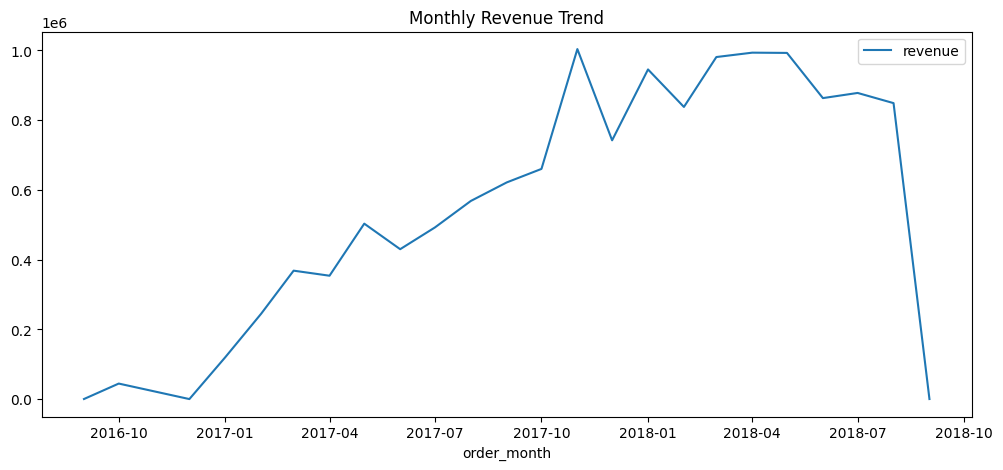

In [16]:
df.plot(
    x="order_month",
    y="revenue",
    kind="line",
    figsize=(12, 5),
    title="Monthly Revenue Trend"
)

<Axes: title={'center': 'Monthly Order Trend'}, xlabel='order_month'>

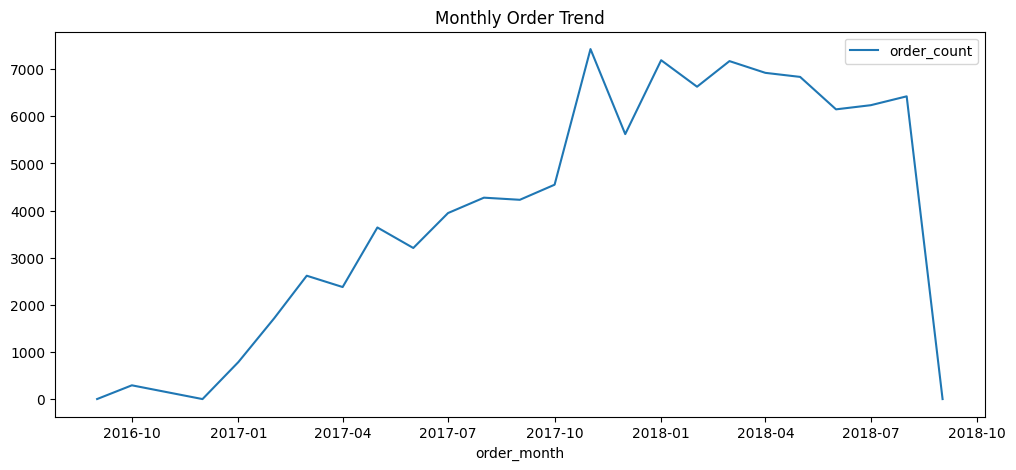

In [17]:
df.plot(
    x="order_month",
    y="order_count",
    kind="line",
    figsize=(12, 5),
    title="Monthly Order Trend"
)

<Axes: title={'center': 'Orders vs Revenue'}, xlabel='order_count', ylabel='revenue'>

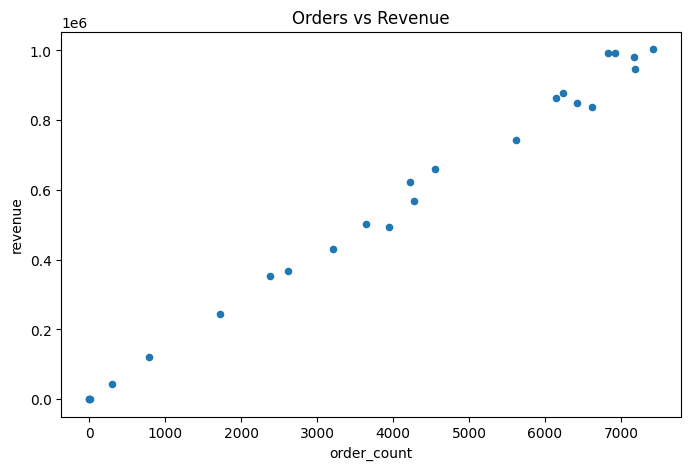

In [18]:
df.plot(
    x="order_count",
    y="revenue",
    kind="scatter",
    figsize=(8, 5),
    title="Orders vs Revenue"
)

In [19]:
df[["order_count", "revenue"]].corr()


,order_count,revenue
order_count,1.000000,0.996305
revenue,0.996305,1.000000


<Axes: title={'center': 'Monthly Average Order Value Trend'}, xlabel='order_month'>

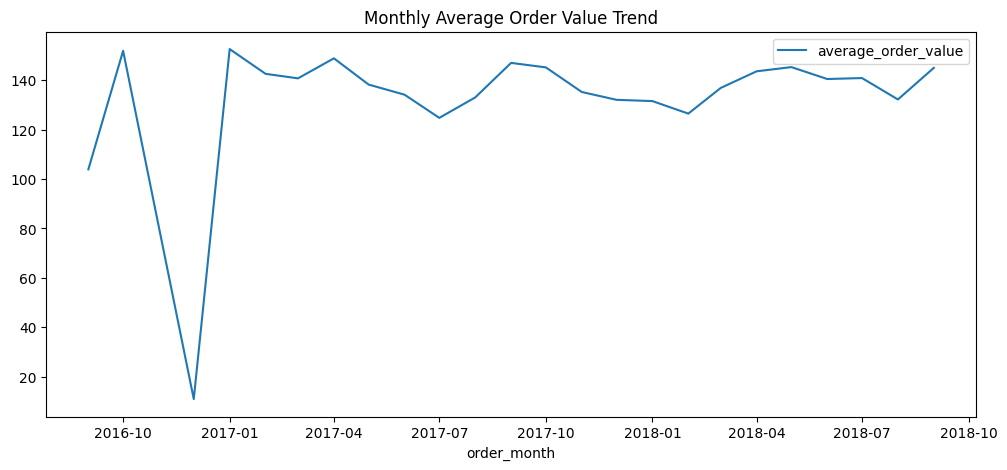

In [20]:
df.plot(
    x="order_month",
    y="average_order_value",
    kind="line",
    figsize=(12, 5),
    title="Monthly Average Order Value Trend"
)

In [21]:
query = """
SELECT *
FROM `ordermetrics360.ordermetrics360_marts.mart_revenue_trend`
"""

df = client.query(query).to_dataframe()

df.tail()

/Users/student/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_month,order_count,revenue,average_order_value
19,2018-05-01,6833,992871.75,145.305393
20,2018-06-01,6145,863265.53,140.482592
21,2018-07-01,6233,878044.27,140.870250
22,2018-08-01,6421,848860.10,132.200607
23,2018-09-01,1,145.00,145.000000


In [22]:
query = """
SELECT *
FROM `ordermetrics360.ordermetrics360_marts.mart_rfm`
"""

rfm_df = client.query(query).to_dataframe()

rfm_df.head()

/Users/student/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,customer_unique_id,recency,frequency,monetary
0,0a0a92112bd4c708ca5fde585afaa872,339,1,13664.08
1,da122df9eeddfedc1dc1f5349a1a690c,520,2,7571.63
2,763c8b1c9c68a0229c42c9fc6f662b93,50,1,7274.88
3,dc4802a71eae9be1dd28f5d788ceb526,568,1,6929.31
4,459bef486812aa25204be022145caa62,40,1,6922.21


In [23]:
rfm_df.describe()

,recency,frequency,monetary
count,94990.0,94990.0,94989.000000
mean,243.349479,1.033867,165.694312
std,153.000542,0.210826,226.740844
min,0.0,1.0,9.590000
25%,119.0,1.0,63.100000
50%,224.0,1.0,107.900000
75%,352.0,1.0,182.940000
max,729.0,16.0,13664.080000


In [24]:
rfm_df["frequency"].value_counts().sort_index()

frequency
1     92102
2      2652
3       188
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: Int64

In [25]:
revenue_df = client.query("""
SELECT *
FROM `ordermetrics360.ordermetrics360_marts.mart_revenue_trend`
""").to_dataframe()

rfm_df = client.query("""
SELECT *
FROM `ordermetrics360.ordermetrics360_marts.mart_rfm`
""").to_dataframe()

delivery_df = client.query("""
SELECT *
FROM `ordermetrics360.ordermetrics360_marts.mart_delivery_reviews`
""").to_dataframe()

category_df = client.query("""
SELECT *
FROM `ordermetrics360.ordermetrics360_marts.mart_category_performance`
""").to_dataframe()

cohort_df = client.query("""
SELECT *
FROM `ordermetrics360.ordermetrics360_marts.mart_cohort_retention`
""").to_dataframe()

print("All 5 marts loaded successfully!")

/Users/student/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


All 5 marts loaded successfully!


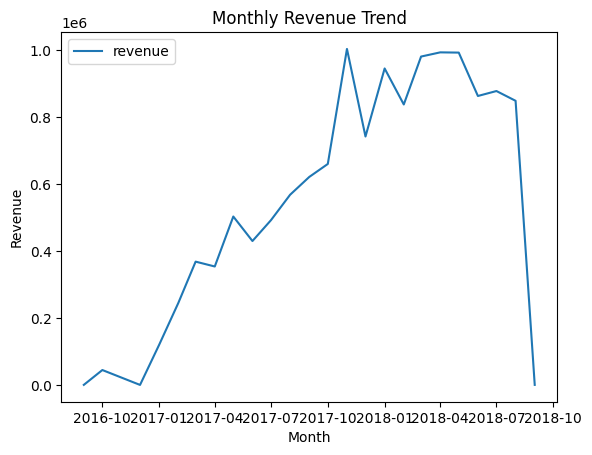

In [26]:
import matplotlib.pyplot as plt

revenue_df.plot(
    x='order_month',
    y='revenue',
    kind='line',
    title='Monthly Revenue Trend'
)

plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

In [27]:
revenue_df.describe()

,order_count,revenue,average_order_value
count,24.0,2.400000e+01,24.000000
mean,4091.958333,5.622667e+05,132.646840
std,2605.963303,3.552003e+05,27.919899
min,1.0,1.090000e+01,10.900000
25%,2212.25,3.266221e+05,132.165749
50%,4249.5,5.948309e+05,139.356570
75%,6472.0,8.669602e+05,145.047538
max,7423.0,1.003862e+06,152.602630


In [28]:
revenue_df[['order_count', 'revenue', 'average_order_value']].corr()

,order_count,revenue,average_order_value
order_count,1.000000,0.996305,0.279396
revenue,0.996305,1.000000,0.300510
average_order_value,0.279396,0.300510,1.000000


In [29]:
rfm_df[['recency', 'frequency', 'monetary']].describe()

,recency,frequency,monetary
count,94990.0,94990.0,94989.000000
mean,243.349479,1.033867,165.694312
std,153.000542,0.210826,226.740844
min,0.0,1.0,9.590000
25%,119.0,1.0,63.100000
50%,224.0,1.0,107.900000
75%,352.0,1.0,182.940000
max,729.0,16.0,13664.080000


In [30]:
rfm_df['frequency'].value_counts().sort_index()

frequency
1     92102
2      2652
3       188
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: Int64

In [31]:
rfm_df.sort_values('monetary', ascending=False).head(10)

,customer_unique_id,recency,frequency,monetary
0,0a0a92112bd4c708ca5fde585afaa872,339,1,13664.08
1,da122df9eeddfedc1dc1f5349a1a690c,520,2,7571.63
2,763c8b1c9c68a0229c42c9fc6f662b93,50,1,7274.88
3,dc4802a71eae9be1dd28f5d788ceb526,568,1,6929.31
4,459bef486812aa25204be022145caa62,40,1,6922.21
5,ff4159b92c40ebe40454e3e6a7c35ed6,467,1,6726.66
6,4007669dec559734d6f53e029e360987,283,1,6081.54
7,eebb5dda148d3893cdaf5b5ca3040ccb,503,1,4764.34
8,48e1ac109decbb87765a3eade6854098,73,1,4681.78
9,c8460e4251689ba205045f3ea17884a1,26,4,4655.91


In [32]:
rfm_df.sort_values('monetary', ascending=False).head(10)

,customer_unique_id,recency,frequency,monetary
0,0a0a92112bd4c708ca5fde585afaa872,339,1,13664.08
1,da122df9eeddfedc1dc1f5349a1a690c,520,2,7571.63
2,763c8b1c9c68a0229c42c9fc6f662b93,50,1,7274.88
3,dc4802a71eae9be1dd28f5d788ceb526,568,1,6929.31
4,459bef486812aa25204be022145caa62,40,1,6922.21
5,ff4159b92c40ebe40454e3e6a7c35ed6,467,1,6726.66
6,4007669dec559734d6f53e029e360987,283,1,6081.54
7,eebb5dda148d3893cdaf5b5ca3040ccb,503,1,4764.34
8,48e1ac109decbb87765a3eade6854098,73,1,4681.78
9,c8460e4251689ba205045f3ea17884a1,26,4,4655.91


In [33]:
delivery_df['delivery_delay_days'].describe()

count      96476.0
mean    -11.876881
std      10.183854
min         -147.0
25%          -17.0
50%          -12.0
75%           -7.0
max          188.0
Name: delivery_delay_days, dtype: Float64

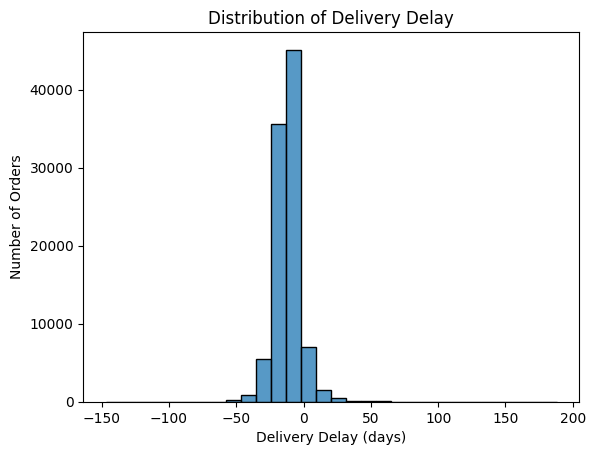

In [34]:
import seaborn as sns

sns.histplot(delivery_df['delivery_delay_days'], bins=30)

plt.title('Distribution of Delivery Delay')
plt.xlabel('Delivery Delay (days)')
plt.ylabel('Number of Orders')
plt.show()

In [35]:
category_df.sort_values('revenue', ascending=False).head(10)

,product_category,order_count,revenue,average_review_score
0,health_beauty,8836,1258681.34,4.181203
1,watches_gifts,5624,1205005.68,4.065459
2,bed_bath_table,9417,1036988.68,3.970740
3,sports_leisure,7720,988048.97,4.167362
4,computers_accessories,6689,911954.32,4.026245
5,furniture_decor,6449,729762.49,4.009691
6,cool_stuff,3632,635290.85,4.169630
7,housewares,5884,632248.66,4.142221
8,auto,3897,592720.11,4.090147
9,garden_tools,3518,485256.46,4.136156


In [36]:
for name, df in [
    ('revenue', revenue_df),
    ('rfm', rfm_df),
    ('delivery', delivery_df),
    ('category', category_df)
]:
    print(name, df.isnull().sum().sum(), 'nulls')

revenue 0 nulls
rfm 1 nulls
delivery 646 nulls
category 0 nulls


In [37]:
rfm_df[rfm_df.isnull().any(axis=1)]

,customer_unique_id,recency,frequency,monetary
94989,830d5b7aaa3b6f1e9ad63703bec97d23,718,1,NaN


In [38]:
delivery_df.isnull().sum()

order_id                           0
customer_unique_id                 0
order_purchase_timestamp           0
order_delivered_customer_date      0
order_estimated_delivery_date      0
review_score                     646
delivery_delay_days                0
dtype: int64

## EDA Findings

- Monthly order count and revenue show a very strong positive relationship.
- Most customers are one-time buyers, while only a small percentage are repeat customers.
- A small number of customers have relatively high monetary value.
- Delivery delay is mostly negative, indicating that many orders were delivered before the estimated date.
- Some orders have missing review scores, but delivery delay values are complete.
- Revenue is concentrated in a few major product categories, while review scores vary across categories.
- RFM contains one missing monetary value, which should be treated as a data-quality observation.

In [39]:
import pandas as pd

# Recency: lower is better, so reverse the scoring
rfm_df['R_score'] = pd.qcut(
    rfm_df['recency'],
    4,
    labels=[4, 3, 2, 1]
).astype(int)

# Frequency: higher is better
rfm_df['F_score'] = pd.qcut(
    rfm_df['frequency'].rank(method='first'),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

# Monetary: higher is better
rfm_df['M_score'] = pd.qcut(
    rfm_df['monetary'].fillna(rfm_df['monetary'].median()),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

# Combined RFM score
rfm_df['RFM_score'] = (
    rfm_df['R_score'].astype(str)
    + rfm_df['F_score'].astype(str)
    + rfm_df['M_score'].astype(str)
)

In [40]:
# Create a copy for scoring
rfm_scored = rfm_df.dropna(subset=['monetary']).copy()

# Recency: lower is better
rfm_scored['R_score'] = pd.qcut(
    rfm_scored['recency'],
    4,
    labels=[4, 3, 2, 1]
).astype(int)

# Frequency: higher is better
rfm_scored['F_score'] = pd.qcut(
    rfm_scored['frequency'].rank(method='first'),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

# Monetary: higher is better
rfm_scored['M_score'] = pd.qcut(
    rfm_scored['monetary'],
    4,
    labels=[1, 2, 3, 4]
).astype(int)

# Combined RFM score
rfm_scored['RFM_score'] = (
    rfm_scored['R_score'].astype(str)
    + rfm_scored['F_score'].astype(str)
    + rfm_scored['M_score'].astype(str)
)

print("Original customers:", len(rfm_df))
print("Customers scored:", len(rfm_scored))
print("Excluded due to missing monetary:", len(rfm_df) - len(rfm_scored))

Original customers: 94990
Customers scored: 94989
Excluded due to missing monetary: 1


In [41]:
def segment_customer(row):
    if row['R_score'] >= 3 and row['F_score'] >= 3 and row['M_score'] >= 3:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 2:
        return 'Loyal Customers'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['F_score'] <= 2 and row['M_score'] <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'


rfm_scored['segment'] = rfm_scored.apply(segment_customer, axis=1)

rfm_scored[['R_score', 'F_score', 'M_score', 'RFM_score', 'segment']].head()

,R_score,F_score,M_score,RFM_score,segment
0,2,1,4,214,Needs Attention
1,1,4,4,144,At Risk
2,4,1,4,414,Needs Attention
3,1,1,4,114,Needs Attention
4,4,1,4,414,Needs Attention


In [42]:
rfm_scored['segment'].value_counts()

segment
Loyal Customers    34177
Needs Attention    34089
At Risk            23922
Champions           1407
Lost                1394
Name: count, dtype: int64

In [43]:
rfm_scored.groupby('segment')['monetary'].agg(
    ['sum', 'mean', 'count']
).sort_values('sum', ascending=False)

,sum,mean,count
segment,,,
Needs Attention,10352325.38,303.685218,34089
Loyal Customers,2975778.48,87.069622,34177
At Risk,1780842.21,74.443701,23922
Champions,483358.68,343.538507,1407
Lost,146832.26,105.331607,1394


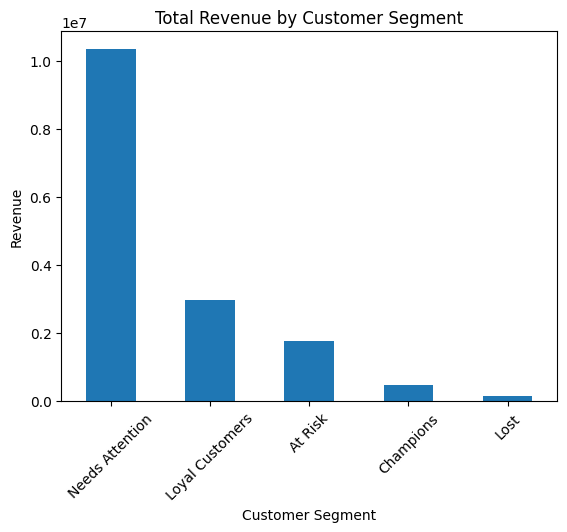

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

segment_revenue = (
    rfm_scored.groupby('segment')['monetary']
    .sum()
    .sort_values(ascending=False)
)

segment_revenue.plot(
    kind='bar',
    title='Total Revenue by Customer Segment'
)

plt.ylabel('Revenue')
plt.xlabel('Customer Segment')
plt.xticks(rotation=45)
plt.show()

In [45]:
import os
os.makedirs("data/processed", exist_ok=True)

In [46]:
rfm_scored.to_csv('data/processed/rfm_segmented.csv', index=False)

print("RFM segmented file saved successfully!")

RFM segmented file saved successfully!


In [47]:
import os

os.makedirs('data/processed', exist_ok=True)

print("Folder created successfully!")

Folder created successfully!


In [48]:
rfm_scored.to_csv('data/processed/rfm_segmented.csv', index=False)

print("RFM segmented file saved successfully!")

RFM segmented file saved successfully!


## RFM Segmentation Findings

- Loyal Customers and Needs Attention are the largest customer segments.
- Champions represent a small customer group but have the highest average monetary value per customer.
- Needs Attention contributes the largest total revenue among the customer segments.
- The segmentation shows that customer value is not evenly distributed across all segments.

In [49]:
delivery_df.head()

,order_id,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,review_score,delivery_delay_days
0,bfbd0f9bdef84302105ad712db648a6c,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09-15 12:16:38+00:00,2016-11-09 07:47:38+00:00,2016-10-04 00:00:00+00:00,1,36
1,3b697a20d9e427646d92567910af6d57,32ea3bdedab835c3aa6cb68ce66565ef,2016-10-03 09:44:50+00:00,2016-10-26 14:02:13+00:00,2016-10-27 00:00:00+00:00,4,-1
2,be5bc2f0da14d8071e2d45451ad119d9,2f64e403852e6893ae37485d5fcacdaf,2016-10-03 16:56:50+00:00,2016-10-27 18:19:38+00:00,2016-11-07 00:00:00+00:00,4,-11
3,31b0dd6152d2e471443debf037ae171d,4e23e1826902ec9f208e8cc61329b494,2016-10-05 12:32:55+00:00,2016-10-13 16:03:46+00:00,2016-11-23 00:00:00+00:00,5,-41
4,cd3b8574c82b42fc8129f6d502690c3e,87776adb449c551e74c13fc34f036105,2016-10-03 22:31:31+00:00,2016-10-14 16:08:00+00:00,2016-11-23 00:00:00+00:00,5,-40


In [50]:
delivery_df.columns

Index(['order_id', 'customer_unique_id', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_score', 'delivery_delay_days'],
      dtype='object')

In [51]:
delivery_df['on_time'] = delivery_df['delivery_delay_days'] <= 0

In [52]:
delivery_df['on_time'].value_counts()

on_time
True     89941
False     6535
Name: count, dtype: Int64

In [53]:
on_time_scores = delivery_df[
    delivery_df['on_time']
]['review_score'].dropna()

delayed_scores = delivery_df[
    ~delivery_df['on_time']
]['review_score'].dropna()

print("On-time orders with reviews:", len(on_time_scores))
print("Delayed orders with reviews:", len(delayed_scores))

print("On-time average review:", on_time_scores.mean())
print("Delayed average review:", delayed_scores.mean())

On-time orders with reviews: 89448
Delayed orders with reviews: 6382
On-time average review: 4.292382166174761
Delayed average review: 2.274052021309934


In [54]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    on_time_scores,
    delayed_scores,
    alternative='two-sided'
)

print(f"U-statistic: {stat}")
print(f"p-value: {p_value}")

U-statistic: 467423734.5
p-value: 0.0


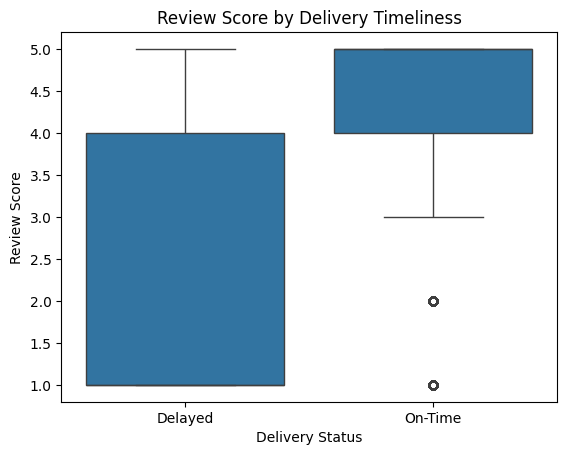

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = delivery_df.dropna(subset=['review_score']).copy()

sns.boxplot(
    x='on_time',
    y='review_score',
    data=plot_df
)

plt.xticks([0, 1], ['Delayed', 'On-Time'])
plt.title('Review Score by Delivery Timeliness')
plt.xlabel('Delivery Status')
plt.ylabel('Review Score')
plt.show()

## Hypothesis Testing — Delivery Delay vs Review Score

- On-time/early deliveries had an average review score of **4.29 stars**, while delayed deliveries had an average of **2.27 stars**.
- A **Mann–Whitney U test** found a statistically significant difference in review scores between the two groups (**U = 467,423,734.5, p < 0.001**).
- This indicates a strong association between delivery timeliness and customer review scores.
- The result does not by itself prove that delivery delay causes lower review scores.

In [56]:
payment_df = client.query("""
    SELECT
        r.order_id,
        p.payment_type,
        r.review_score
    FROM `ordermetrics360.ordermetrics360_marts.mart_delivery_reviews` r
    JOIN `ordermetrics360.stg_order_payments` p
        USING(order_id)
""").to_dataframe()

payment_df.head()

/Users/student/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_id,payment_type,review_score
0,02190241f7190a1f3c7e0df95a749c6a,boleto,<NA>
1,5da2004d85f2828349d887c989da2adc,boleto,<NA>
2,c776863a93dc0740c6e7d78104b21413,credit_card,<NA>
3,fbd82b1fe98967de0db29b6cf134d00a,credit_card,<NA>
4,05cd156f0f47579a36d7a52724fc31b8,credit_card,<NA>


In [57]:
tables = client.query("""
    SELECT
        table_schema,
        table_name
    FROM `ordermetrics360.region-asia-south1`.INFORMATION_SCHEMA.TABLES
    WHERE table_name LIKE '%payment%'
    ORDER BY table_schema, table_name
""").to_dataframe()

tables

/Users/student/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,table_schema,table_name
0,ordermetrics360,order_payments
1,ordermetrics360,stg_order_payments


In [58]:
payment_df = client.query("""
    SELECT
        r.order_id,
        p.payment_type,
        r.review_score
    FROM `ordermetrics360.ordermetrics360_marts.mart_delivery_reviews` r
    JOIN `ordermetrics360.ordermetrics360.stg_order_payments` p
        USING(order_id)
    WHERE r.review_score IS NOT NULL
""").to_dataframe()

payment_df.head()

/Users/student/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_id,payment_type,review_score
0,d207cc272675637bfed0062edffd0818,credit_card,1
1,79ffdd52a918bbe867895a4b183d6457,credit_card,1
2,98974b076b01553d49ee6467905675a7,credit_card,1
3,ed8c7b1b3eb256c70ce0c74231e1da88,credit_card,1
4,6b3ee7697a02619a0ace2b3f0aa46bde,credit_card,1


In [59]:
payment_df['order_id'].nunique(), len(payment_df)

(95829, 100078)

In [60]:
payment_df = client.query("""
    WITH payment_per_order AS (
        SELECT
            order_id,
            ARRAY_AGG(
                STRUCT(payment_type, payment_value)
                ORDER BY payment_value DESC
                LIMIT 1
            )[OFFSET(0)] AS primary_payment
        FROM `ordermetrics360.ordermetrics360.stg_order_payments`
        GROUP BY order_id
    )

    SELECT
        r.order_id,
        p.primary_payment.payment_type AS payment_type,
        r.review_score
    FROM `ordermetrics360.ordermetrics360_marts.mart_delivery_reviews` r
    JOIN payment_per_order p
        USING(order_id)
    WHERE r.review_score IS NOT NULL
""").to_dataframe()

payment_df.head()

/Users/student/Library/Python/3.9/lib/python/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,order_id,payment_type,review_score
0,45ed6e85398a87c253db47c2d9f48216,voucher,1
1,2122719f6fc72fba16b0b3001d539a7e,voucher,1
2,00c405bd71187154a7846862f585a9d4,voucher,1
3,f12388e0e8c7694fc38c8de19261054c,voucher,1
4,67937bb4e0c9a4156fe47c89382d33e7,voucher,1


In [61]:
payment_df['order_id'].nunique(), len(payment_df)

(95829, 95829)

In [62]:
payment_df['satisfied'] = payment_df['review_score'] >= 4

payment_df[['payment_type', 'review_score', 'satisfied']].head()

,payment_type,review_score,satisfied
0,voucher,1,False
1,voucher,1,False
2,voucher,1,False
3,voucher,1,False
4,voucher,1,False


In [63]:
contingency = pd.crosstab(
    payment_df['payment_type'],
    payment_df['satisfied']
)

contingency

satisfied,False,True
payment_type,,
boleto,4022,15040
credit_card,15163,57174
debit_card,277,1200
voucher,666,2287


In [64]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Chi-square statistic:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 8.960964659157316
p-value: 0.029814410039980057
Degrees of freedom: 3


In [65]:
satisfaction_pct = (
    contingency.div(contingency.sum(axis=1), axis=0) * 100
)

satisfaction_pct

satisfied,False,True
payment_type,,
boleto,21.099570,78.900430
credit_card,20.961610,79.038390
debit_card,18.754232,81.245768
voucher,22.553336,77.446664


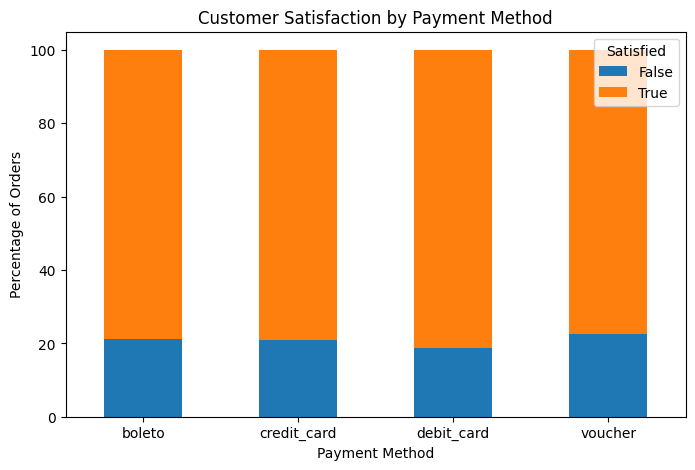

In [66]:
import matplotlib.pyplot as plt

satisfaction_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Customer Satisfaction by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Percentage of Orders')
plt.xticks(rotation=0)
plt.legend(title='Satisfied')
plt.show()

## Hypothesis Testing — Payment Method vs Satisfaction

- Customer satisfaction was defined as a review score of **4 or 5 stars**.
- A **Chi-square test of independence** was used to examine the relationship between payment method and satisfaction.
- The test returned **χ² = 8.961**, **df = 3**, and **p = 0.0298**.
- Since p < 0.05, there is statistical evidence of an association between payment method and customer satisfaction.
- Satisfaction rates were relatively close across payment methods, ranging from **77.45% to 81.25%**.
- Therefore, payment method shows a statistically detectable association with satisfaction in this dataset, but the observed differences in satisfaction rates are relatively small.
- This test identifies association, not causation.